<a href="https://colab.research.google.com/github/Danny3636/Generative-AI-Tasks/blob/main/Task11_FlowMatching_Floorplan_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From this task, I've learned how to train a Flow Matching generative model using floorplan images. I've seen how to define a U-Net architecture and implement the Flow Matching logic to predict a velocity field. Finally, I successfully used the trained model to generate new, synthetic floorplans through an Euler ODE solver.

# Task 11 – Flow Matching for Synthetic Floorplan Generation

Adapted from **MLM9 – Flow Matching – Receipt Generation**.

This notebook trains a Flow Matching generative model on floorplan images and uses the learned velocity field to synthesise new, unseen floorplans.

**Before running:**
1. Set runtime to **GPU** → Runtime → Change runtime type → L4 / T4
2. Upload `floorplans_v2-20251223T170650Z-3-001.zip` to `/content/` (use the file browser on the left)

## 1. Setup and Hyperparameters

Import necessary libraries and define global hyperparameters that configure our model and training process.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import glob
import zipfile
from PIL import Image

# Check for GPU availability and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define Hyperparameters
HPARAMS = {
    "img_size":         128,    # Resize floorplans to 128x128 (balance quality / VRAM)
    "inference_steps":  100,    # Euler ODE solver steps during generation
    "batch_size":       32,     # Adjust down if you hit OOM on your GPU
    "lr":               1e-4,   # Adam learning rate
    "epochs":           50,     # Training epochs
    "channels":         1,      # 1 = grayscale (floorplans are mostly line drawings)
    "num_classes":      1,      # Single class: 'floorplan'
}
print("Hyperparameters:", HPARAMS)

Using device: cuda
Hyperparameters: {'img_size': 128, 'inference_steps': 100, 'batch_size': 32, 'lr': 0.0001, 'epochs': 50, 'channels': 1, 'num_classes': 1}


## 2. Data Extraction

Extract floorplan images from the provided ZIP file into a working directory.

In [3]:
ZIP_FILENAME = "floorplans_v2-20251223T170650Z-3-001.zip"
EXTRACT_DIR  = "floorplan_images"

# Search common Colab locations for the zip
search_paths = [
    os.path.join("/content", ZIP_FILENAME),
    os.path.join("/content/drive/MyDrive", ZIP_FILENAME),
    os.path.join(".", ZIP_FILENAME),
]

zip_path = None
for p in search_paths:
    if os.path.exists(p):
        zip_path = p
        break

if zip_path is None:
    print(f"\u26a0\ufe0f  Could not find {ZIP_FILENAME} automatically.")
    print("    Please upload it to /content/ or set zip_path manually.")
else:
    print(f"Found zip at: {zip_path}")
    if not os.path.isdir(EXTRACT_DIR):
        print("Extracting floorplan images ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(EXTRACT_DIR)
        print(f"Extracted to '{EXTRACT_DIR}/'")
    else:
        print(f"'{EXTRACT_DIR}/' already exists - skipping extraction.")

Found zip at: /content/floorplans_v2-20251223T170650Z-3-001.zip
Extracting floorplan images ...
Extracted to 'floorplan_images/'


## 3. Model Architecture and Flow Matching Logic

This section defines the core components:

### FloorplanDataset
Custom `Dataset` that recursively loads all images from the extracted directory, converts them to grayscale, and resizes them. All images share a single class label (0).

### SinusoidalPositionEmbeddings
Creates sinusoidal positional embeddings for time steps. These help the network understand the 'progress' of the generation process (from noise to data).

### Block
Fundamental building block of the U-Net: convolutional layers + batch normalisation + ReLU + time-embedding injection. The `transform` layer handles downsampling or upsampling.

### ConditionalUNet
The main neural network. A U-Net variant conditioned on (time step t) + (class embedding c). Encoder blocks downsample; decoder blocks upsample with skip connections.

### FlowMatching
Implements Optimal-Transport Conditional Flow Matching (OT-CFM):
- **`compute_loss`**: samples noise x_0, data x_1, random time t; computes interpolant x_t = (1-t)*x_0 + t*x_1; trains the model to predict the velocity v = x_1 - x_0.
- **`sample`**: Euler ODE solver from t=0 (noise) to t=1 (generated image) following the learned velocity field.

In [4]:
# ─── Dataset ───────────────────────────────────────────────────────────

class FloorplanDataset(Dataset):
    """
    Loads floorplan images from a directory tree.
    Converts to grayscale and resizes to (img_size x img_size).
    All images share a single class label (0).
    """
    EXTENSIONS = ("jpg", "jpeg", "png", "bmp", "tiff", "webp")

    def __init__(self, root_dir, img_size=128, transform=None):
        super().__init__()
        self.transform = transform
        self.image_paths = []
        for ext in self.EXTENSIONS:
            self.image_paths.extend(
                glob.glob(os.path.join(root_dir, "**", f"*.{ext}"), recursive=True)
            )
        if not self.image_paths:
            raise RuntimeError(
                f"No images found under {root_dir}. "
                "Check that the zip was extracted correctly."
            )
        print(f"Found {len(self.image_paths)} floorplan images under {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        label = 0  # single-class
        return img, label


# ─── Model Architecture ───────────────────────────────────────────────

class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes a scalar time-step into a fixed-size sinusoidal vector."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=time.device) * -emb)
        emb = time[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class Block(nn.Module):
    """
    A single encoder / decoder block of the U-Net.
    Two convolutions with BatchNorm + ReLU, time-embedding injection,
    and a spatial transform (downsample or upsample).
    """
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1     = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(...,) + (None,) * 2]          # -> (B, C, 1, 1)
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)


class ConditionalUNet(nn.Module):
    """
    A lightweight conditional U-Net that predicts the velocity field v(x, t).
    Conditioning is on (time-step t) + (class embedding c).
    """
    def __init__(self):
        super().__init__()
        img_ch   = HPARAMS["channels"]
        time_dim = 32
        down_ch  = (32, 64, 128)
        up_ch    = (128, 64, 32)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(),
        )
        self.class_emb = nn.Embedding(HPARAMS["num_classes"], time_dim)
        self.conv0     = nn.Conv2d(img_ch, down_ch[0], 3, padding=1)

        self.downs = nn.ModuleList(
            [Block(down_ch[i], down_ch[i + 1], time_dim) for i in range(len(down_ch) - 1)]
        )
        self.ups = nn.ModuleList(
            [Block(up_ch[i], up_ch[i + 1], time_dim, up=True) for i in range(len(up_ch) - 1)]
        )
        self.output = nn.Conv2d(up_ch[-1], img_ch, 1)

    def forward(self, x, t_float, class_label):
        t = self.time_mlp(t_float)
        c = self.class_emb(class_label)
        t = t + c

        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            residual = residuals.pop()
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
        return self.output(x)


# ─── Flow Matching Logic ──────────────────────────────────────────────

class FlowMatching:
    """
    Implements Optimal-Transport Conditional Flow Matching (OT-CFM).

    Training:  learn v_theta(x_t, t) approx (x_1 - x_0)  along the straight path
               x_t = (1-t)*x_0 + t*x_1  with x_0 ~ N(0,I), x_1 ~ p_data.

    Sampling:  solve the ODE  dx/dt = v_theta(x, t)  from t=0 to t=1 with Euler.
    """
    def __init__(self):
        pass

    def compute_loss(self, model, x_1, labels):
        b = x_1.shape[0]
        x_0 = torch.randn_like(x_1)                           # noise
        t   = torch.rand(b, device=x_1.device)                 # random time
        t_v = t.view(b, 1, 1, 1)
        x_t = (1 - t_v) * x_0 + t_v * x_1                     # interpolant
        v_target = x_1 - x_0                                   # true velocity
        v_pred   = model(x_t, t, labels)                       # predicted vel.
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, model, n_samples, class_label_idx, size, steps=50):
        """Generate n_samples floorplans via Euler ODE integration."""
        model.eval()
        x = torch.randn(n_samples, HPARAMS["channels"], size, size, device=device)
        labels = torch.full((n_samples,), class_label_idx, dtype=torch.long, device=device)
        dt = 1.0 / steps

        for i in range(steps):
            t_curr = torch.full((n_samples,), i / steps, device=device)
            v_pred = model(x, t_curr, labels)
            x = x + v_pred * dt

        model.train()
        return x

## 4. Train the Flow Matching Model

This cell trains the ConditionalUNet on the floorplan dataset. A preview grid is shown every 10 epochs so you can track visual progress.

Found 1000 floorplan images under floorplan_images
Model parameters: 929,441
Starting training for 50 epochs ...



Epoch 1/50: 100%|██████████| 32/32 [00:07<00:00,  4.28it/s, loss=1.2651]


  -> Epoch 1 avg loss: 1.5686


Epoch 2/50: 100%|██████████| 32/32 [00:05<00:00,  5.66it/s, loss=1.0948]


  -> Epoch 2 avg loss: 1.1764


...

  -> Epoch 8 avg loss: 0.2908


Epoch 9/50: 100%|██████████| 32/32 [00:05<00:00,  5.51it/s, loss=0.4056]


  -> Epoch 9 avg loss: 0.2296


Epoch 10/50: 100%|██████████| 32/32 [00:05<00:00,  5.51it/s, loss=0.1511]


  -> Epoch 10 avg loss: 0.1868


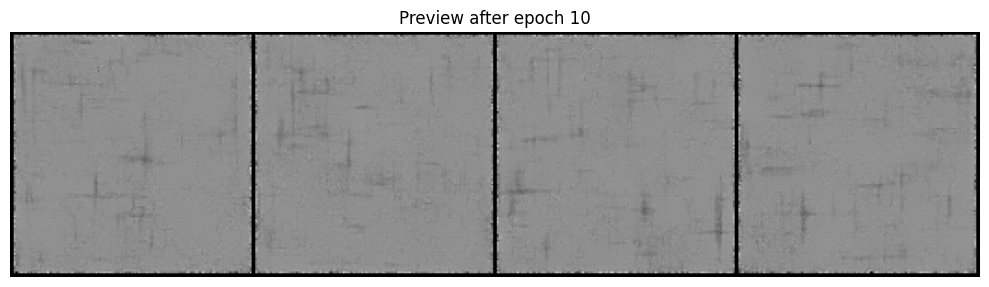

Epoch 11/50: 100%|██████████| 32/32 [00:05<00:00,  5.45it/s, loss=0.2040]


  -> Epoch 11 avg loss: 0.1850


Epoch 12/50: 100%|██████████| 32/32 [00:05<00:00,  5.38it/s, loss=0.1305]


  -> Epoch 12 avg loss: 0.1646


Epoch 13/50: 100%|██████████| 32/32 [00:05<00:00,  5.34it/s, loss=0.1207]


...

  -> Epoch 18 avg loss: 0.1415


Epoch 19/50: 100%|██████████| 32/32 [00:06<00:00,  5.06it/s, loss=0.1163]


  -> Epoch 19 avg loss: 0.1382


Epoch 20/50: 100%|██████████| 32/32 [00:06<00:00,  4.98it/s, loss=0.1070]


  -> Epoch 20 avg loss: 0.1415


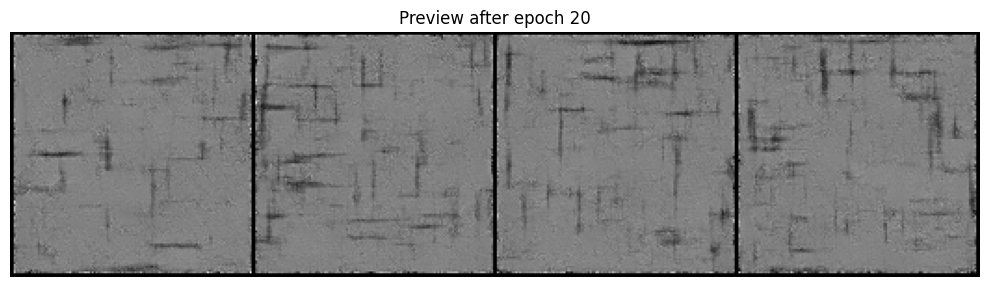

Epoch 21/50: 100%|██████████| 32/32 [00:06<00:00,  4.91it/s, loss=0.1124]


  -> Epoch 21 avg loss: 0.1366


Epoch 22/50: 100%|██████████| 32/32 [00:06<00:00,  4.87it/s, loss=0.1025]


  -> Epoch 22 avg loss: 0.1346


Epoch 23/50: 100%|██████████| 32/32 [00:06<00:00,  4.87it/s, loss=0.2096]


...

  -> Epoch 28 avg loss: 0.1221


Epoch 29/50: 100%|██████████| 32/32 [00:06<00:00,  5.07it/s, loss=0.0931]


  -> Epoch 29 avg loss: 0.1174


Epoch 30/50: 100%|██████████| 32/32 [00:06<00:00,  5.06it/s, loss=0.1051]


  -> Epoch 30 avg loss: 0.1150


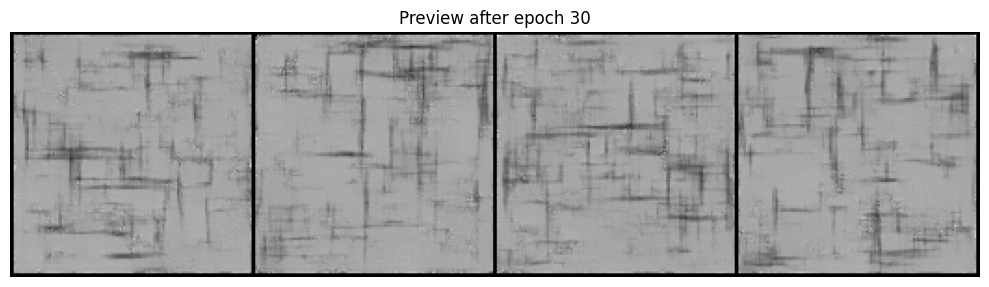

Epoch 31/50: 100%|██████████| 32/32 [00:06<00:00,  5.02it/s, loss=0.1226]


  -> Epoch 31 avg loss: 0.1216


Epoch 32/50: 100%|██████████| 32/32 [00:06<00:00,  5.01it/s, loss=0.1239]


  -> Epoch 32 avg loss: 0.1179


Epoch 33/50: 100%|██████████| 32/32 [00:06<00:00,  4.94it/s, loss=0.2491]


...

  -> Epoch 38 avg loss: 0.1140


Epoch 39/50: 100%|██████████| 32/32 [00:06<00:00,  5.00it/s, loss=0.0857]


  -> Epoch 39 avg loss: 0.1092


Epoch 40/50: 100%|██████████| 32/32 [00:06<00:00,  5.00it/s, loss=0.1740]


  -> Epoch 40 avg loss: 0.1081


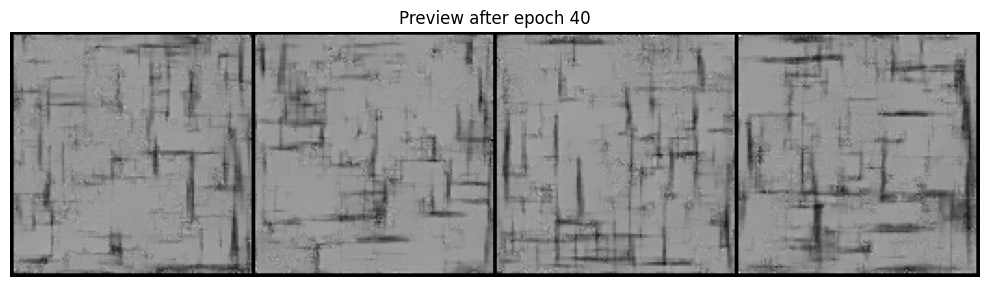

Epoch 41/50: 100%|██████████| 32/32 [00:06<00:00,  4.99it/s, loss=0.1826]


  -> Epoch 41 avg loss: 0.1118


Epoch 42/50: 100%|██████████| 32/32 [00:06<00:00,  5.01it/s, loss=0.1124]


  -> Epoch 42 avg loss: 0.1117


Epoch 43/50: 100%|██████████| 32/32 [00:06<00:00,  5.01it/s, loss=0.0886]


...

  -> Epoch 48 avg loss: 0.1071


Epoch 49/50: 100%|██████████| 32/32 [00:06<00:00,  4.94it/s, loss=0.1154]


  -> Epoch 49 avg loss: 0.1057


Epoch 50/50: 100%|██████████| 32/32 [00:06<00:00,  4.94it/s, loss=0.1010]


  -> Epoch 50 avg loss: 0.1059


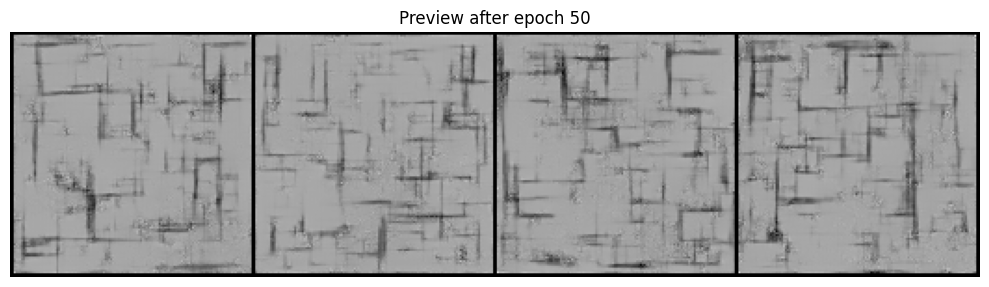

In [5]:
def train_floorplan_model():
    """End-to-end training: data loading -> model init -> optimisation loop."""

    # Dataset & DataLoader
    tfm = transforms.Compose([
        transforms.Resize((HPARAMS["img_size"], HPARAMS["img_size"])),
        transforms.ToTensor(),
    ])
    dataset    = FloorplanDataset(EXTRACT_DIR, img_size=HPARAMS["img_size"], transform=tfm)
    dataloader = DataLoader(dataset, batch_size=HPARAMS["batch_size"],
                            shuffle=True, num_workers=2, pin_memory=True)

    # Model / Optimiser
    model     = ConditionalUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS["lr"])
    flow      = FlowMatching()

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")
    print(f"Starting training for {HPARAMS['epochs']} epochs ...\n")

    loss_history = []

    for epoch in range(HPARAMS["epochs"]):
        epoch_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{HPARAMS['epochs']}")
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            loss = flow.compute_loss(model, images, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"  -> Epoch {epoch+1} avg loss: {avg_loss:.4f}")

        # Show a small preview every 10 epochs
        if (epoch + 1) % 10 == 0 or (epoch + 1) == HPARAMS["epochs"]:
            preview = flow.sample(model, n_samples=4, class_label_idx=0,
                                  size=HPARAMS["img_size"], steps=HPARAMS["inference_steps"])
            grid = make_grid(preview, nrow=4, normalize=True, padding=2)
            plt.figure(figsize=(10, 3))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
            plt.title(f"Preview after epoch {epoch+1}")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    return model, flow, loss_history

# Run training
trained_model, flow_manager, loss_history = train_floorplan_model()

## 5. Save the Trained Model

In [6]:
MODEL_FILENAME = "floorplan_flow_model.pth"

def save_model(model, filename=MODEL_FILENAME):
    torch.save(model.state_dict(), filename)
    print(f"Model saved to {filename}")

save_model(trained_model)

Model saved to floorplan_flow_model.pth


## 6. Training Loss Curve

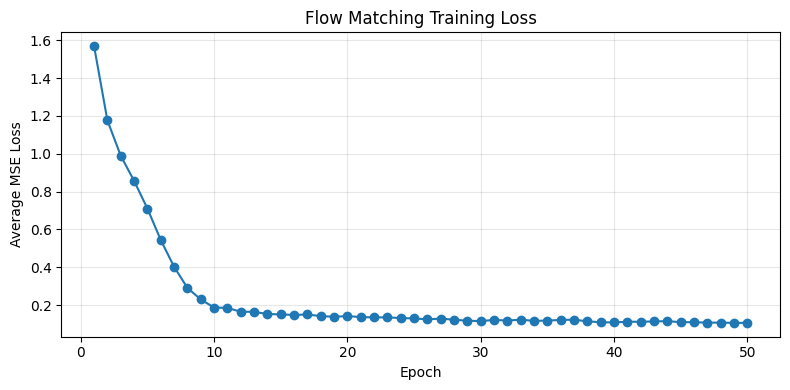

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Flow Matching Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Generate New Synthetic Floorplans

Now that the model is trained, we generate a grid of synthetic floorplan images using the Euler ODE solver.


Generating 12 synthetic floorplans (100 Euler steps) ...


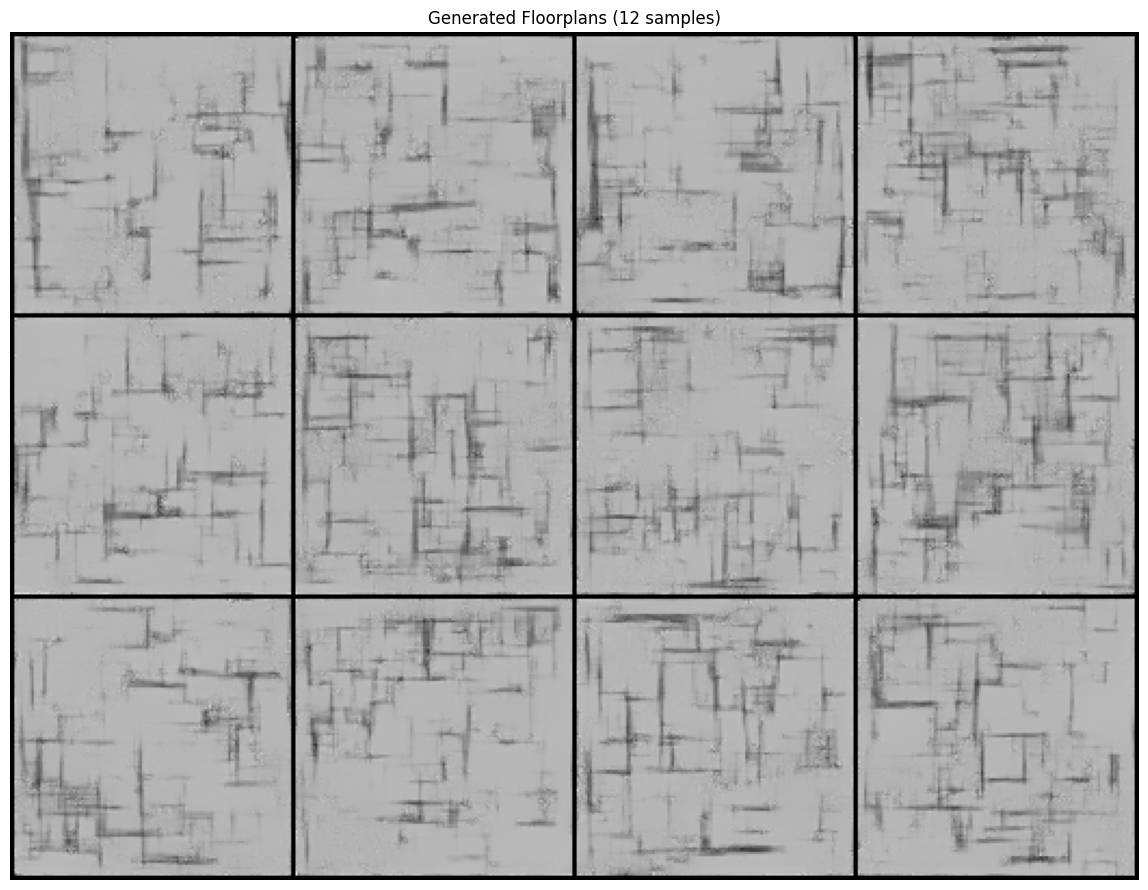

In [8]:
def generate_floorplan_grid(model, flow, rows=3, cols=4):
    n = rows * cols
    print(f"\nGenerating {n} synthetic floorplans ({HPARAMS['inference_steps']} Euler steps) ...")
    samples = flow.sample(model, n_samples=n, class_label_idx=0,
                          size=HPARAMS["img_size"], steps=HPARAMS["inference_steps"])
    grid = make_grid(samples, nrow=cols, normalize=True, padding=2)

    plt.figure(figsize=(3 * cols, 3 * rows))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.title(f"Generated Floorplans ({n} samples)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

generate_floorplan_grid(trained_model, flow_manager, rows=3, cols=4)

## 8. Generate a Single Floorplan Image

Load the saved model and generate a single high-quality synthetic floorplan.

Model loaded from floorplan_flow_model.pth
Generating new floorplan with ODE Solver...


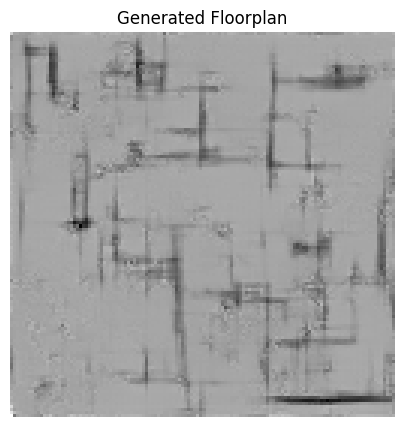

In [9]:
def load_model(filename=MODEL_FILENAME):
    if not os.path.exists(filename):
        print(f"Error: {filename} not found.")
        return None
    model = ConditionalUNet().to(device)
    model.load_state_dict(torch.load(filename, map_location=device))
    model.eval()
    print(f"Model loaded from {filename}")
    return model

def generate_single_floorplan(model, flow, doc_type='floorplan'):
    """Generates a single floorplan image."""
    label_map = {'floorplan': 0}

    if doc_type not in label_map:
        print(f"Unknown type: {doc_type}.")
        return

    print(f"Generating new {doc_type} with ODE Solver...")
    sample_tensor = flow.sample(model, n_samples=1, class_label_idx=label_map[doc_type],
                                size=HPARAMS["img_size"], steps=HPARAMS["inference_steps"])

    img = sample_tensor[0].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"Generated {doc_type.capitalize()}")
    plt.axis('off')
    plt.show()

# Load the saved model and generate
loaded_model = load_model(MODEL_FILENAME)
flow_gen = FlowMatching()

if loaded_model:
    generate_single_floorplan(loaded_model, flow_gen, doc_type='floorplan')